# NHS BNF Regional Prescribing Analysis

## Introduction

This project analyses NHS prescribing data using the BNF regional summary dataset from the NHSBSA Prescription Cost Analysis (PCA) database.

The analysis explores prescribing activity across NHS regions using the British National Formulary (BNF) hierarchy, including BNF chapters and sections.

The project aims to identify:
- prescribing trends across healthcare categories
- regional prescribing variation
- prescribing cost patterns
- high-volume healthcare categories
- operational healthcare insights relevant to NHS planning

In [29]:
# Import Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Apply consistent chart styling
plt.style.use('ggplot')

print("Libraries imported successfully")

Libraries imported successfully


# Load Dataset

The NHS BNF regional prescribing summary dataset is loaded into the notebook for analysis.

In [30]:
# Load NHS BNF regional summary dataset

summary_data = pd.read_csv("../data/BSA_ODP_PCA_REGIONAL_SUMMARY.csv")

# Display first five rows
summary_data.head()

,YEAR_MONTH,REGION_NAME,ITEMS,COST
0,202101,EAST OF ENGLAND,796466,3406002.61
1,202101,LONDON,678021,3205663.66
2,202101,MIDLANDS,1249416,5698605.43
3,202101,NORTH EAST AND YORKSHIRE,1428677,5741978.96
4,202101,NORTH WEST,1003963,4435228.70


# Data Inspection

Initial data inspection is performed to understand the dataset structure, data types, missing values, and overall dataset quality before analysis.

In [31]:
# Check dataset dimensions

summary_data.shape

(322, 4)

In [32]:
# Display dataset information and data types

summary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR_MONTH   322 non-null    int64  
 1   REGION_NAME  322 non-null    str    
 2   ITEMS        322 non-null    int64  
 3   COST         322 non-null    float64
dtypes: float64(1), int64(2), str(1)
memory usage: 10.2 KB


In [33]:
# Generate summary statistics for numerical variables

summary_data.describe()

,YEAR_MONTH,ITEMS,COST
count,322.000000,3.220000e+02,3.220000e+02
mean,202249.760870,1.034402e+06,2.894256e+06
std,109.559108,3.050428e+05,8.440603e+05
min,202101.000000,6.387520e+05,1.580214e+06
25%,202112.000000,7.983028e+05,2.189782e+06
50%,202211.500000,9.155985e+05,2.784099e+06
75%,202311.000000,1.303790e+06,3.456533e+06
max,202410.000000,1.845998e+06,6.146084e+06


### Summary Statistics Interpretation

The summary statistics show substantial variation in prescribing activity and prescribing costs across NHS healthcare categories and regions.

The dataset contains 322 observations covering prescribing activity between 2021 and 2024.

Key observations include:

- Average prescribing volume was approximately 1.03 million prescription items.
- Average prescribing cost was approximately £2.89 million.
- Prescribing volumes ranged from approximately 638,752 items to 1.85 million items.
- Prescribing costs ranged from approximately £1.58 million to £6.15 million.

The large variation between minimum and maximum values suggests differences in prescribing demand, healthcare utilisation, and prescribing costs across NHS prescribing categories over time.

In [34]:
# Check for missing values

summary_data.isnull().sum()

YEAR_MONTH     0
REGION_NAME    0
ITEMS          0
COST           0
dtype: int64

In [35]:
# Check for duplicate records

summary_data.duplicated().sum()

np.int64(0)

# Data Cleaning

The dataset is reviewed for missing values, duplicate records, and appropriate data types before further analysis.

In [36]:
# Convert YEAR_MONTH column into datetime format

summary_data['YEAR_MONTH'] = pd.to_datetime(
    summary_data['YEAR_MONTH'].astype(str),
    format='%Y%m'
)

# Confirm updated data types
summary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR_MONTH   322 non-null    datetime64[us]
 1   REGION_NAME  322 non-null    str           
 2   ITEMS        322 non-null    int64         
 3   COST         322 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 10.2 KB


# Feature Engineering

Additional time-based features are created to support monthly, quarterly, and seasonal analysis.

In [37]:
# Create additional time-based features

summary_data['Month'] = summary_data['YEAR_MONTH'].dt.month
summary_data['Month_Name'] = summary_data['YEAR_MONTH'].dt.month_name()
summary_data['Quarter'] = summary_data['YEAR_MONTH'].dt.quarter

# Display updated dataset
summary_data.head()

,YEAR_MONTH,REGION_NAME,ITEMS,COST,Month,Month_Name,Quarter
0,2021-01-01,EAST OF ENGLAND,796466,3406002.61,1,January,1
1,2021-01-01,LONDON,678021,3205663.66,1,January,1
2,2021-01-01,MIDLANDS,1249416,5698605.43,1,January,1
3,2021-01-01,NORTH EAST AND YORKSHIRE,1428677,5741978.96,1,January,1
4,2021-01-01,NORTH WEST,1003963,4435228.70,1,January,1


# Exploratory Data Analysis

Exploratory analysis is performed to understand prescribing activity across BNF healthcare categories and NHS regions.

# BNF Chapter Analysis

This section explores prescribing activity across major NHS healthcare categories using the British National Formulary (BNF) chapter hierarchy.

# Regional Prescribing Analysis

This section explores prescribing activity across NHS regions to identify regional variation in prescribing demand and prescribing costs.

In [40]:
# Calculate total prescription items by NHS region

regional_items = (
    summary_data.groupby('REGION_NAME')['ITEMS']
    .sum()
    .sort_values(ascending=False)
)

# Display prescribing activity by region

regional_items

REGION_NAME
NORTH EAST AND YORKSHIRE    72090463
MIDLANDS                    62669553
NORTH WEST                  49786016
SOUTH EAST                  41867132
EAST OF ENGLAND             38431318
LONDON                      35896285
SOUTH WEST                  32336814
Name: ITEMS, dtype: int64

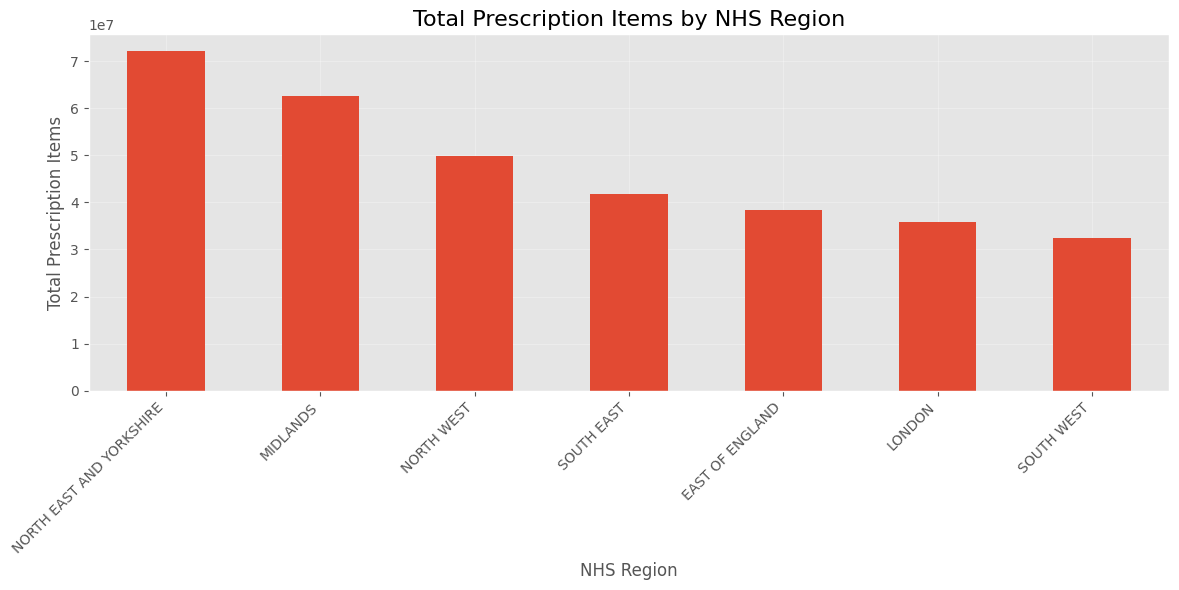

In [42]:
# Plot prescribing activity across NHS regions

ax = regional_items.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Total Prescription Items by NHS Region', fontsize=16)
plt.xlabel('NHS Region', fontsize=12)
plt.ylabel('Total Prescription Items', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Regional Prescribing Cost Analysis

This section analyses prescribing costs across NHS regions to identify variation in healthcare spending and prescribing expenditure.

In [43]:
# Calculate total prescribing cost by NHS region

regional_cost = (
    summary_data.groupby('REGION_NAME')['COST']
    .sum()
    .sort_values(ascending=False)
)

# Display prescribing cost by region

regional_cost

REGION_NAME
MIDLANDS                    1.761022e+08
NORTH EAST AND YORKSHIRE    1.755055e+08
SOUTH EAST                  1.435012e+08
NORTH WEST                  1.321767e+08
EAST OF ENGLAND             1.058483e+08
LONDON                      1.045064e+08
SOUTH WEST                  9.430996e+07
Name: COST, dtype: float64

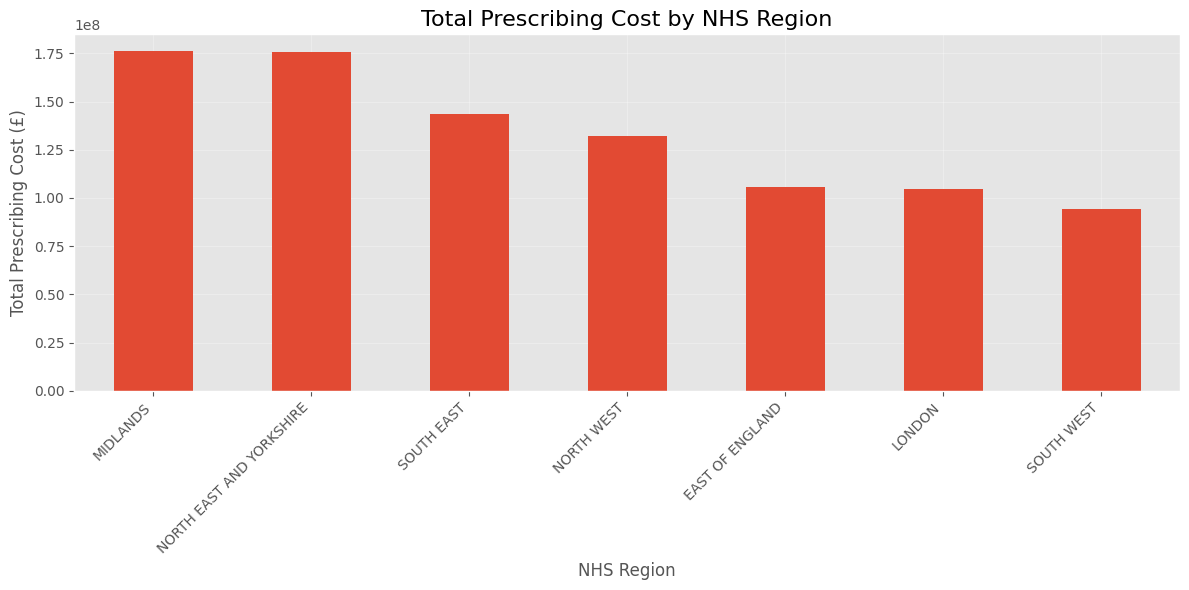

In [44]:
# Plot prescribing cost across NHS regions

ax = regional_cost.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Total Prescribing Cost by NHS Region', fontsize=16)
plt.xlabel('NHS Region', fontsize=12)
plt.ylabel('Total Prescribing Cost (£)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The regional prescribing cost analysis shows noticeable variation in prescribing expenditure across NHS regions.

Key observations include:

- The Midlands recorded the highest overall prescribing cost, closely followed by North East and Yorkshire.
- The South East and North West also showed relatively high prescribing expenditure.
- London and the South West recorded comparatively lower prescribing costs.

The findings highlight the importance of monitoring regional prescribing expenditure to support NHS resource allocation and healthcare financial planning.

# Monthly Prescribing Trend Analysis

This section analyses monthly prescribing activity over time to identify long-term prescribing trends across NHS regions.

In [45]:
# Calculate monthly prescribing volume

monthly_items = (
    summary_data.groupby('YEAR_MONTH')['ITEMS']
    .sum()
)

# Display monthly prescribing trend

monthly_items.head()

YEAR_MONTH
2021-01-01    6711605
2021-02-01    6337714
2021-03-01    7129148
2021-04-01    6895434
2021-05-01    6597509
Name: ITEMS, dtype: int64

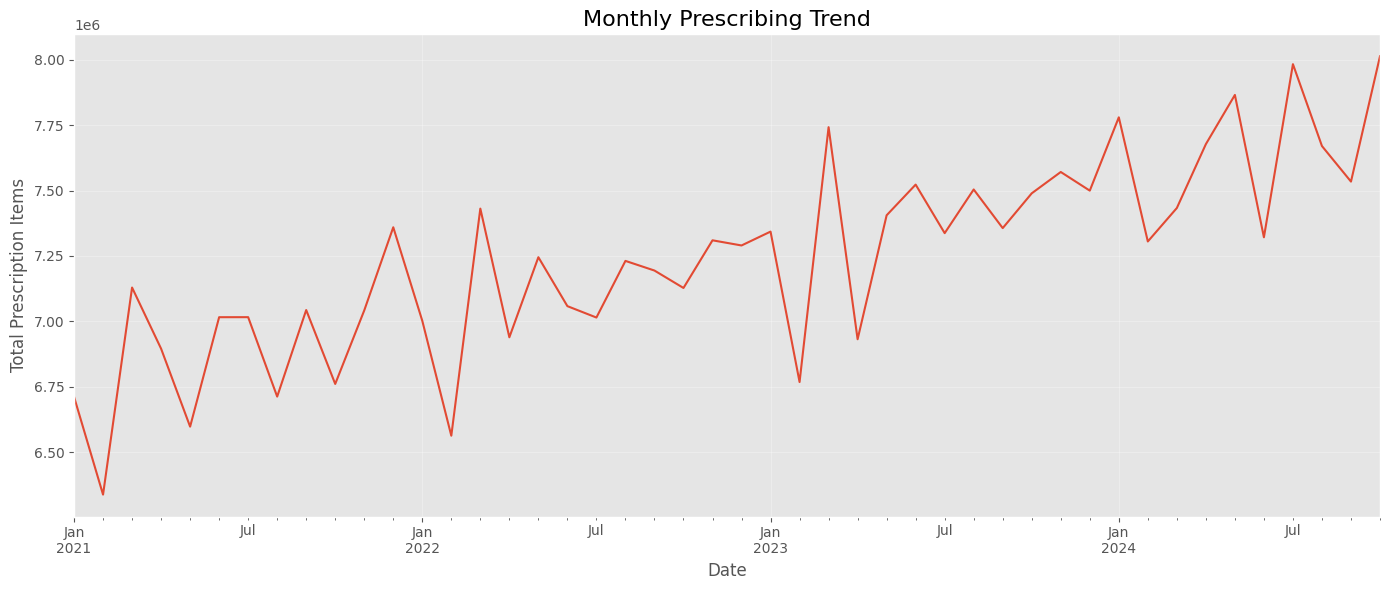

In [46]:
# Plot monthly prescribing trend

ax = monthly_items.plot(
    figsize=(14,6)
)

plt.title('Monthly Prescribing Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Prescription Items', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The monthly prescribing trend analysis shows a gradual increase in prescribing activity between 2021 and 2024.

Key observations include:

- Monthly prescription volumes generally increased over time.
- Prescribing activity fluctuated slightly across months but maintained an overall upward trend.
- Prescription volumes reached their highest levels during 2024.


# Monthly Prescribing Cost Trend Analysis

This section analyses prescribing expenditure over time to identify trends in NHS prescribing costs across the study period.

In [47]:
# Calculate monthly prescribing cost

monthly_cost = (
    summary_data.groupby('YEAR_MONTH')['COST']
    .sum()
)

# Display monthly prescribing cost trend

monthly_cost.head()

YEAR_MONTH
2021-01-01    30211076.90
2021-02-01    28478445.17
2021-03-01    31933609.64
2021-04-01    24695554.55
2021-05-01    23672108.18
Name: COST, dtype: float64

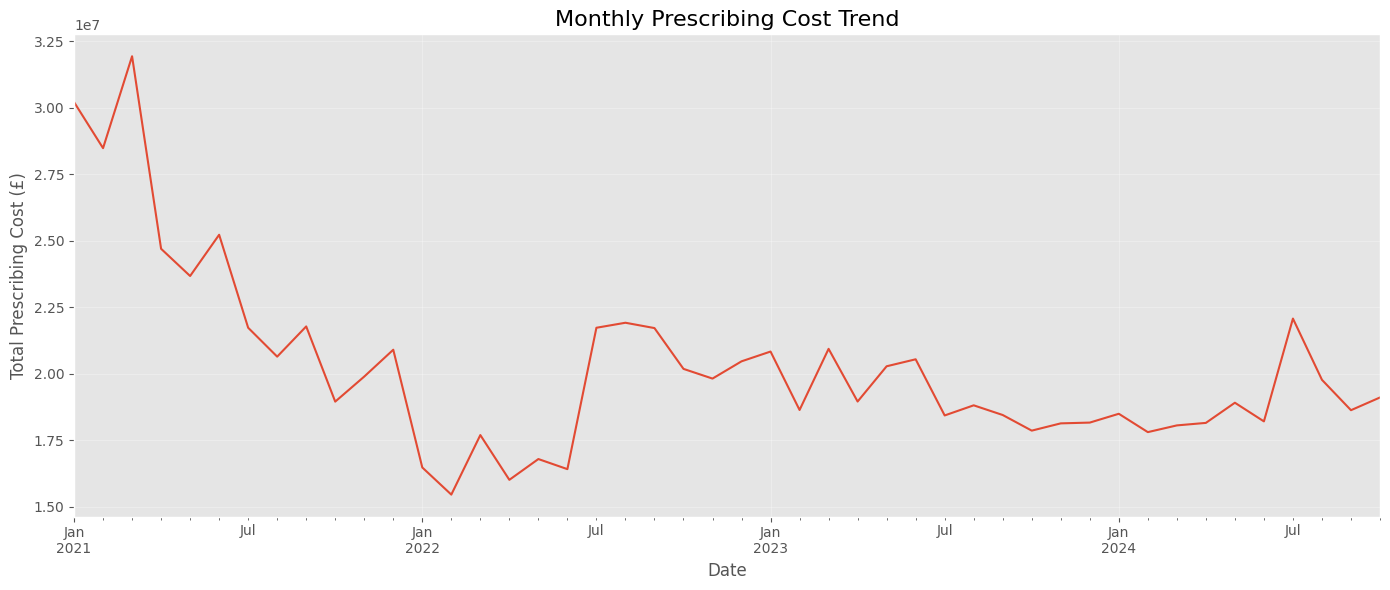

In [48]:
# Plot monthly prescribing cost trend

ax = monthly_cost.plot(
    figsize=(14,6)
)

plt.title('Monthly Prescribing Cost Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Prescribing Cost (£)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The monthly prescribing cost trend analysis shows that prescribing expenditure generally declined between 2021 and 2024 despite increasing prescription volumes.

Key observations include:

- Prescribing costs were highest during early 2021.
- Prescribing expenditure gradually decreased over time.
- Monthly cost fluctuations remained visible throughout the analysis period.
- Cost levels stabilised during 2023 and 2024 compared to earlier periods.

# Cost Efficiency Analysis

This section evaluates prescribing efficiency by analysing the average cost per prescription item over time.

In [49]:
# Calculate average cost per prescription item

summary_data['Cost_Per_Item'] = (
    summary_data['COST'] / summary_data['ITEMS']
)

# Display updated dataset

summary_data.head()

,YEAR_MONTH,REGION_NAME,ITEMS,COST,Month,Month_Name,Quarter,Cost_Per_Item
0,2021-01-01,EAST OF ENGLAND,796466,3406002.61,1,January,1,4.276394
1,2021-01-01,LONDON,678021,3205663.66,1,January,1,4.727971
2,2021-01-01,MIDLANDS,1249416,5698605.43,1,January,1,4.561015
3,2021-01-01,NORTH EAST AND YORKSHIRE,1428677,5741978.96,1,January,1,4.019088
4,2021-01-01,NORTH WEST,1003963,4435228.70,1,January,1,4.417721


In [50]:
# Calculate monthly average cost per item

monthly_cost_per_item = (
    summary_data.groupby('YEAR_MONTH')['Cost_Per_Item']
    .mean()
)

# Display monthly cost efficiency trend

monthly_cost_per_item.head()

YEAR_MONTH
2021-01-01    4.549763
2021-02-01    4.541953
2021-03-01    4.531647
2021-04-01    3.627990
2021-05-01    3.634896
Name: Cost_Per_Item, dtype: float64

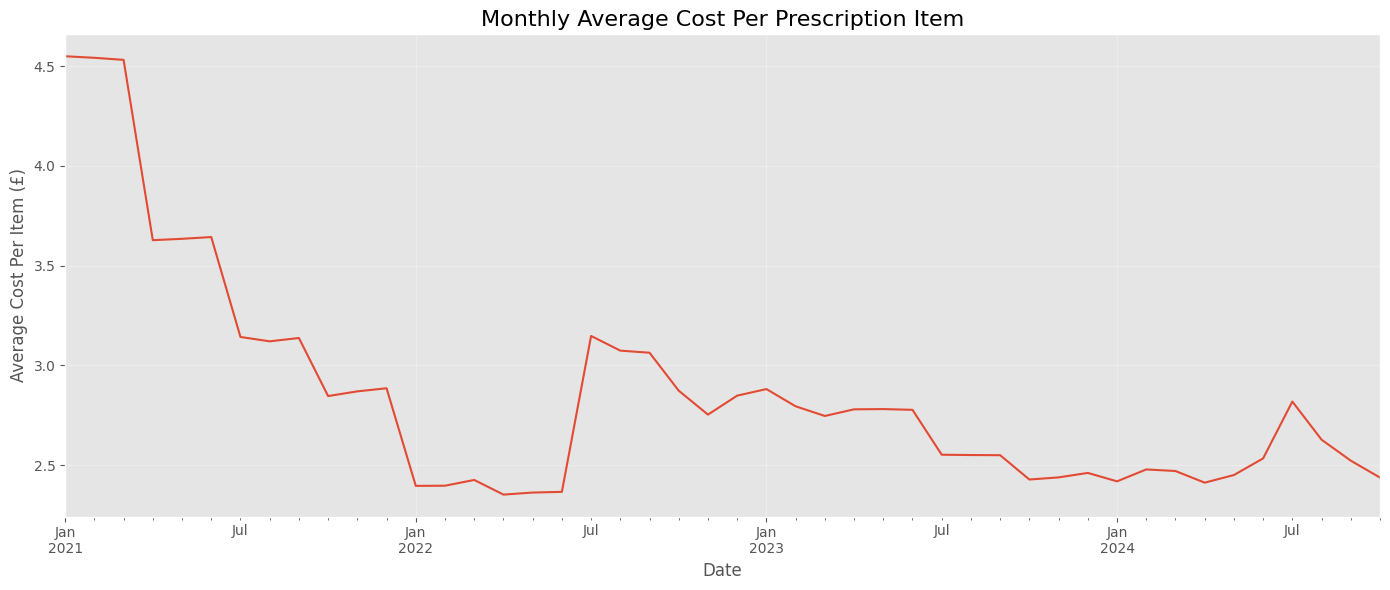

In [52]:
# Plot monthly cost per item trend

ax = monthly_cost_per_item.plot(
    figsize=(14,6)
)

plt.title('Monthly Average Cost Per Prescription Item', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Cost Per Item (£)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The cost efficiency analysis shows that the average prescribing cost per prescription item generally declined between 2021 and 2024.

Key observations include:

- Average prescribing cost per item was highest during early 2021.
- Cost per item decreased steadily over time.
- Cost efficiency stabilised during 2023 and 2024 with lower average prescribing costs per item.

# Key Insights

- North East and Yorkshire recorded the highest prescribing activity across NHS regions.
- The Midlands recorded the highest overall prescribing expenditure.
- Monthly prescribing volumes generally increased between 2021 and 2024.
- Prescribing costs declined over time despite increasing prescription demand.
- Average cost per prescription item decreased throughout the analysis period, suggesting improved prescribing efficiency.
- Regional variation in prescribing demand and prescribing costs highlights differences in healthcare utilisation and operational healthcare pressures across NHS regions.

# Recommendations

Based on the analysis, the following recommendations are suggested:

- Continue monitoring regional prescribing trends to support NHS resource allocation and operational planning.
- Investigate factors contributing to higher prescribing demand in regions such as North East and Yorkshire.
- Monitor prescribing efficiency and cost-per-item trends to support healthcare cost management strategies.
- Explore additional healthcare and demographic data sources to better understand regional prescribing variation.
- Consider future forecasting analysis to support long-term NHS operational planning and healthcare demand prediction.

# Conclusion

This project analysed NHS prescribing data across England to explore prescribing demand, prescribing costs, regional variation, and prescribing efficiency between 2021 and 2024.

The analysis demonstrated increasing prescribing demand across NHS regions alongside improving prescribing cost efficiency over time.

The findings highlight the value of healthcare analytics in supporting NHS operational planning, prescribing monitoring, and healthcare resource management.

The project also demonstrated the importance of combining data analysis, visualisation, and operational interpretation to generate meaningful healthcare insights from NHS prescribing data.